# 01. Exploratory Data Analysis

MIMIC-IV v2.2 (`hosp` module). This notebook loads the raw tables and reproduces the
descriptive views of the cohort: gender mix, care-unit volume, admission source,
seasonality of admissions, and a correlation heatmap of the engineered features.

**Data is not included in this repository.** MIMIC-IV is credentialed data distributed under a
PhysioNet Data Use Agreement. Download it yourself and place the gzipped CSVs under
`data/raw/hosp/`. See the README for the exact layout.


In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 60)

RAW = Path("../data/raw/hosp")
FIG = Path("../figures")
FIG.mkdir(exist_ok=True)

sns.set_theme(style="whitegrid")


def raw(name: str) -> Path:
    """Locate a MIMIC-IV table, accepting either .csv or .csv.gz."""
    for ext in (".csv.gz", ".csv"):
        path = RAW / f"{name}{ext}"
        if path.exists():
            return path
    raise FileNotFoundError(
        f"{name}.csv or {name}.csv.gz not found in {RAW.resolve()}. "
        "See the README for the expected data/raw/hosp layout."
    )


Matplotlib is building the font cache; this may take a moment.


## 1. Load the source tables

In [2]:
usecols = {
    "admissions": [
        "subject_id", "hadm_id", "admittime", "dischtime", "admission_type",
        "admission_location", "insurance", "hospital_expire_flag",
    ],
    "patients": ["subject_id", "gender", "anchor_age"],
    "diagnoses_icd": ["subject_id", "hadm_id", "icd_code", "icd_version"],
    "d_icd_diagnoses": ["icd_code", "icd_version", "long_title"],
    "transfers": ["subject_id", "hadm_id", "careunit"],
}

admissions = pd.read_csv(
    raw("admissions"),
    usecols=usecols["admissions"],
    parse_dates=["admittime", "dischtime"],
)
patients = pd.read_csv(raw("patients"), usecols=usecols["patients"])
diagnoses = pd.read_csv(raw("diagnoses_icd"), usecols=usecols["diagnoses_icd"])
d_icd = pd.read_csv(raw("d_icd_diagnoses"), usecols=usecols["d_icd_diagnoses"])
transfers = pd.read_csv(raw("transfers"), usecols=usecols["transfers"])

print(f"admissions : {admissions.shape}")
print(f"patients   : {patients.shape}")
print(f"diagnoses  : {diagnoses.shape}")
print(f"d_icd      : {d_icd.shape}")
print(f"transfers  : {transfers.shape}")

admissions : (431231, 8)
patients   : (299712, 3)
diagnoses  : (4756326, 4)
d_icd      : (109775, 3)
transfers  : (1890972, 3)


In [3]:
admissions.head()

,subject_id,hadm_id,admittime,dischtime,admission_type,admission_location,insurance,hospital_expire_flag
0,10000032,22595853,2180-05-06 22:23:00,2180-05-07 17:15:00,URGENT,TRANSFER FROM HOSPITAL,Other,0
1,10000032,22841357,2180-06-26 18:27:00,2180-06-27 18:49:00,EW EMER.,EMERGENCY ROOM,Medicaid,0
2,10000032,25742920,2180-08-05 23:44:00,2180-08-07 17:50:00,EW EMER.,EMERGENCY ROOM,Medicaid,0
3,10000032,29079034,2180-07-23 12:35:00,2180-07-25 17:55:00,EW EMER.,EMERGENCY ROOM,Medicaid,0
4,10000068,25022803,2160-03-03 23:16:00,2160-03-04 06:26:00,EU OBSERVATION,EMERGENCY ROOM,Other,0


In [4]:
admissions.info()
admissions.describe(include="all").T.head(10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 431231 entries, 0 to 431230
Data columns (total 8 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   subject_id            431231 non-null  int64         
 1   hadm_id               431231 non-null  int64         
 2   admittime             431231 non-null  datetime64[ns]
 3   dischtime             431231 non-null  datetime64[ns]
 4   admission_type        431231 non-null  object        
 5   admission_location    431231 non-null  object        
 6   insurance             431231 non-null  object        
 7   hospital_expire_flag  431231 non-null  int64         
dtypes: datetime64[ns](2), int64(3), object(3)
memory usage: 26.3+ MB


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
subject_id,431231.0,NaN,NaN,NaN,15007664.969608,10000032.0,12515570.5,15012885.0,17496223.5,19999987.0,2877497.806271
hadm_id,431231.0,NaN,NaN,NaN,25003138.264726,20000019.0,22501549.0,25006691.0,27504698.0,29999928.0,2888180.402945
admittime,431231,NaN,NaN,NaN,2155-02-27 21:07:41.694080,2105-10-04 17:26:00,2135-02-22 13:35:00,2155-01-20 15:22:00,2175-04-05 03:02:00,2212-04-06 12:13:00,NaN
dischtime,431231,NaN,NaN,NaN,2155-03-04 08:43:37.370134528,2105-10-12 11:11:00,2135-02-27 14:04:00,2155-01-24 16:54:00,2175-04-08 22:41:00,2212-04-12 14:06:00,NaN
admission_type,431231,9,EW EMER.,149413,NaN,NaN,NaN,NaN,NaN,NaN,NaN
admission_location,431231,11,EMERGENCY ROOM,232595,NaN,NaN,NaN,NaN,NaN,NaN,NaN
insurance,431231,3,Other,229341,NaN,NaN,NaN,NaN,NaN,NaN,NaN
hospital_expire_flag,431231.0,NaN,NaN,NaN,0.019964,0.0,0.0,0.0,0.0,1.0,0.139876


## 2. Distribution of admitted patients by gender

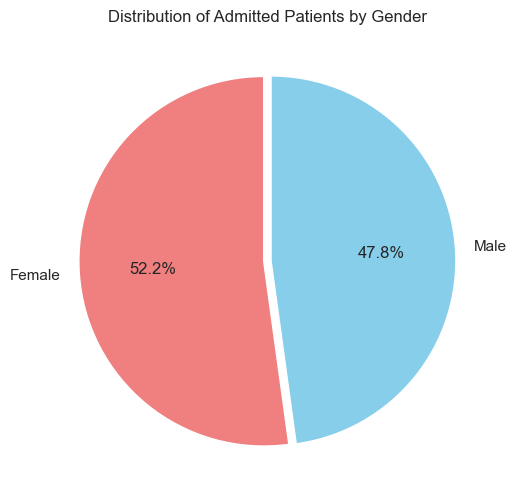

gender
F    52.2
M    47.8
Name: count, dtype: float64

In [5]:
adm_pat = admissions.merge(patients, on="subject_id", how="left")

gender_counts = adm_pat["gender"].value_counts()
labels = {"F": "Female", "M": "Male"}

fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(
    gender_counts,
    labels=[labels.get(g, g) for g in gender_counts.index],
    autopct="%1.1f%%",
    colors=["#f08080", "#87ceeb"],
    startangle=90,
    explode=[0.02] * len(gender_counts),
)
ax.set_title("Distribution of Admitted Patients by Gender")
plt.savefig(FIG / "gender_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

(gender_counts / gender_counts.sum() * 100).round(1)

## 3. Top 10 care units by number of patients

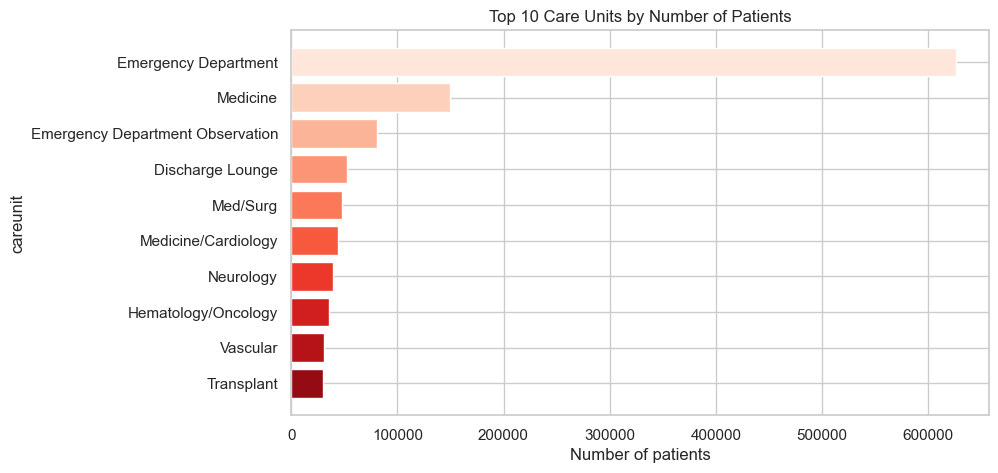

In [6]:
top_units = (
    transfers["careunit"].value_counts().head(10).sort_values(ascending=True)
)

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(top_units.index, top_units.values, color=sns.color_palette("Reds_r", len(top_units)))
ax.set_xlabel("Number of patients")
ax.set_ylabel("careunit")
ax.set_title("Top 10 Care Units by Number of Patients")
plt.savefig(FIG / "top_care_units.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Hospitalisations by admission location

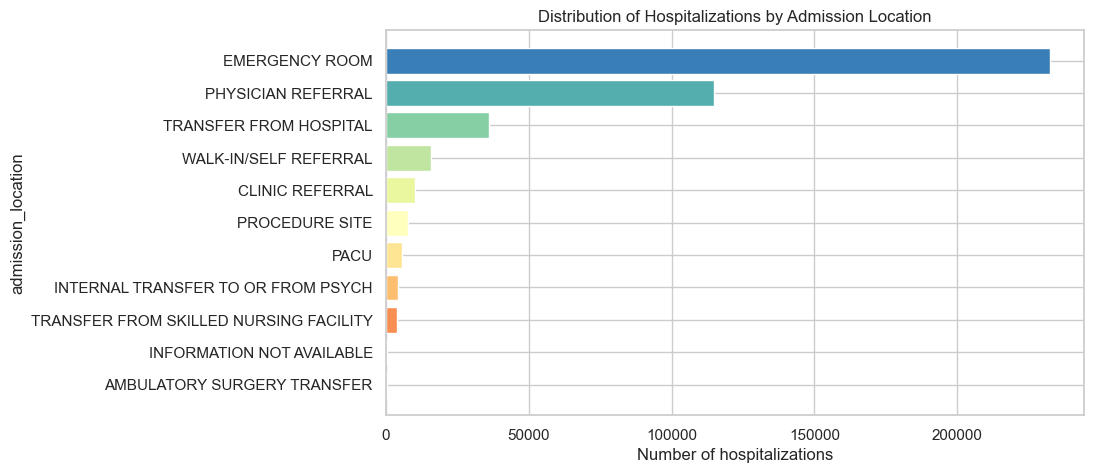

In [7]:
loc_counts = admissions["admission_location"].value_counts().head(11).sort_values()

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(loc_counts.index, loc_counts.values, color=sns.color_palette("Spectral", len(loc_counts)))
ax.set_xlabel("Number of hospitalizations")
ax.set_ylabel("admission_location")
ax.set_title("Distribution of Hospitalizations by Admission Location")
plt.savefig(FIG / "admission_location.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Monthly distribution of admissions

Note that MIMIC-IV admission dates are shifted into the future to protect patient privacy.
Month-of-year is preserved by the shift, so seasonality is still interpretable, but absolute
years are not.


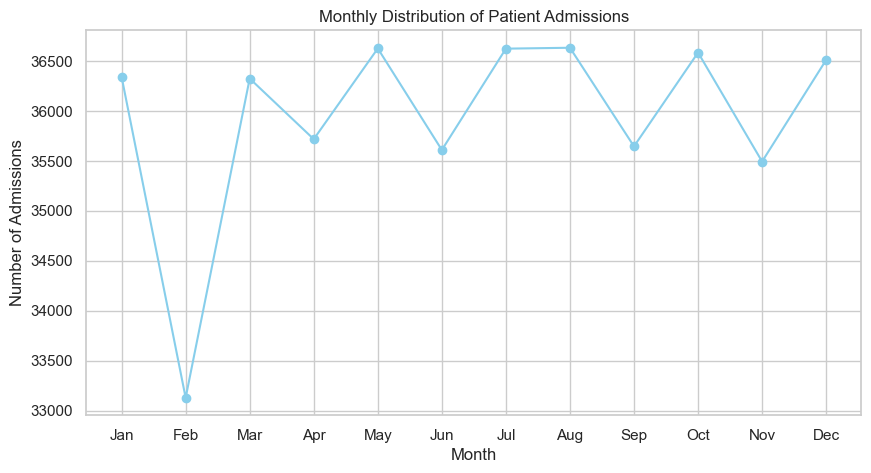

In [8]:
monthly = admissions["admittime"].dt.month.value_counts().sort_index()
month_names = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
               "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(month_names, monthly.values, marker="o", color="#87ceeb")
ax.set_xlabel("Month")
ax.set_ylabel("Number of Admissions")
ax.set_title("Monthly Distribution of Patient Admissions")
plt.savefig(FIG / "monthly_admissions.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Correlation heatmap

Run `02_preprocessing_and_features.ipynb` first so that the kidney cohort exists on disk.


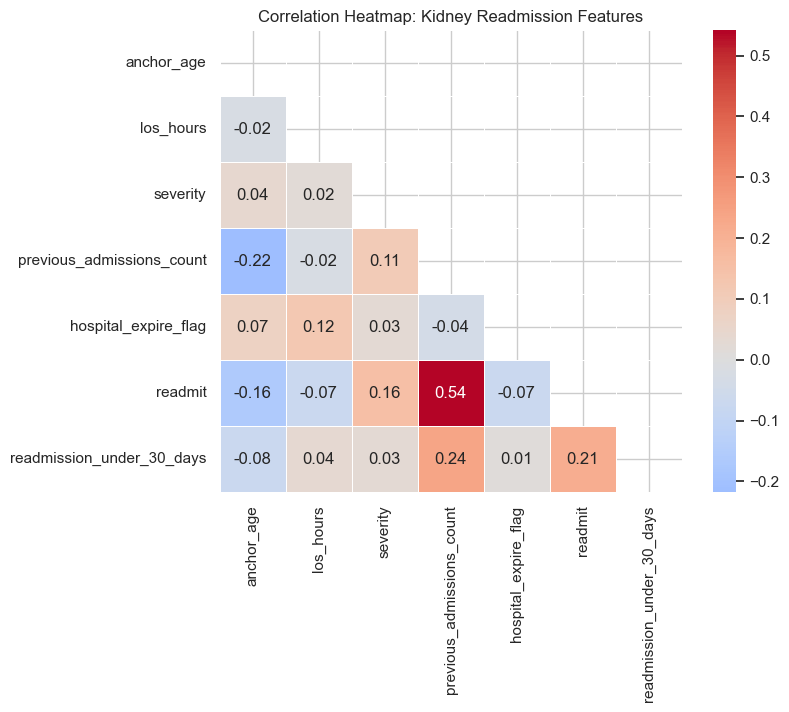

In [9]:
cohort_path = Path("../data/processed/kidney_cohort.parquet")

if cohort_path.exists():
    cohort = pd.read_parquet(cohort_path)
    num_cols = [
        "anchor_age", "los_hours", "severity", "previous_admissions_count",
        "hospital_expire_flag", "readmit", "readmission_under_30_days",
    ]
    corr = cohort[num_cols].corr()
    mask = np.triu(np.ones_like(corr, dtype=bool))

    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
                center=0, square=True, linewidths=0.5, ax=ax)
    ax.set_title("Correlation Heatmap: Kidney Readmission Features")
    plt.savefig(FIG / "correlation_heatmap.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("Run notebook 02 first to generate data/processed/kidney_cohort.parquet")

### Reading the heatmap

`readmit` is the count of prior visits carrying the same ICD code, so it is mechanically related
to the 30-day target. It is kept here to mirror the original analysis, but see `LIMITATIONS.md`
before drawing conclusions from its correlation with the outcome.
